In [1]:
# import sys
# import os
# import warnings
# import uuid

# project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# if project_root not in sys.path:
#     sys.path.append(project_root)

# warnings.filterwarnings("ignore")
# from agents.primary.agent import primary_graph 
import uuid
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import hàm build graph thay vì import graph trực tiếp
# from agents.hotel.agent import hotel_graph as graph 
from agents.primary.agent import build_primary_graph 

# Khởi tạo graph (cần dùng await vì hàm này là async)
graph = await build_primary_graph()

c:\Program Files\Python312\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


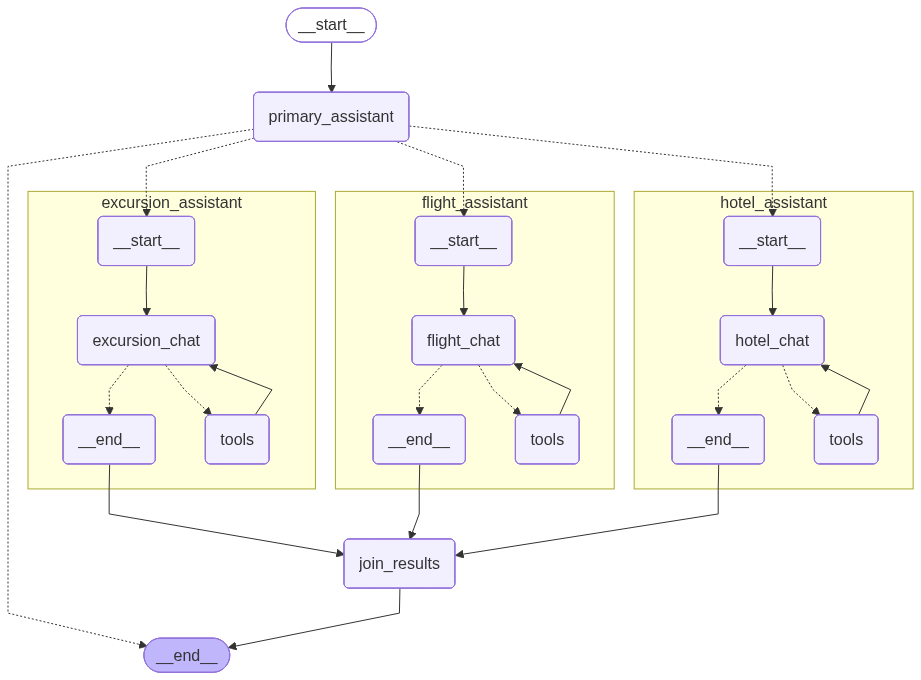

In [2]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [2]:
_printed = set()

def _print_event(event: dict, _printed: set, max_length=5000):
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

In [3]:
tutorial_questions = [
    "Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.",
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    async for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026.
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (6bda1635-a454-4910-8f7d-49c1da7ae2d5)
 Call ID: 6bda1635-a454-4910-8f7d-49c1da7ae2d5
  Args:
================================== Ai Message ==================================

Dưới đây là một số khách sạn ở Hà Nội có sẵn từ ngày 20/07/2026 đến 25/07/2026:

*   **Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội**
    *   ID: 16805122
    *   Giá: 4.249.995 VND
    *   Hạng: Mid
    *   Đánh giá: 0
    *   ![Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội](https://cf.bstatic.com/xdata/images/hotel/square500/891185217.jpg?k=99786eb3ff722fa98ac2cff2fd49315577f0f387fd2329ad4d3321bf8d8f20f4&o=)

*   **The Urbanist - Hanoi Pool Oasis**
    *   ID: 16795752
    *   Giá: 21.000.000 VND
    *   Hạng: Luxury
    *   Đánh giá: 0
    *   ![The Urbani

In [3]:



tutorial_questions = [
    " Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026. tôi muốn kiếm trip ở Đà Nẵng ngày 30/8/2026 ",
    
]

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "passenger_id": "8149 604011",  # ID hành khách (có thể thay đổi để test)
        "thread_id": thread_id,
    }
}

for question in tutorial_questions:
    events = graph.astream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    async for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

 Tìm kiếm khách sạn ở Hà Nội, check in 20/7/2026 và check out 25/7/2026. tôi muốn kiếm trip ở Đà Nẵng ngày 30/8/2026 
================================== Ai Message ==================================
Tool Calls:
  ToHotelAssistant (c722f161-95a0-4348-88e3-d848c45950a0)
 Call ID: c722f161-95a0-4348-88e3-d848c45950a0
  Args:
  ToExcursionAssistant (aece3323-34e2-4c41-b32c-8185ddd86d45)
 Call ID: aece3323-34e2-4c41-b32c-8185ddd86d45
  Args:
================================== Ai Message ==================================

Dưới đây là các khách sạn ở Hà Nội từ ngày 20/07/2026 đến 25/07/2026:
*   **Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội** (external_hotel_id: 16805122)
    Giá: 849.999 VND/đêm, tổng 4.249.995 VND
    ![Lakenest Realty 21, Âu Cơ, Tây Hồ, Hà Nội](https://cf.bstatic.com/xdata/images/hotel/square500/891185217.jpg?k=99786eb3ff722fa98ac2cff2fd49315577f0f387fd2329ad4d3321bf8d8f20f4&o=)
*   **The Urba